<a href="https://colab.research.google.com/github/Addy48/23FE10CSE00457_MLWine/blob/main/MLCar_Price_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc,
    mean_squared_error, r2_score, mean_absolute_error
)

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

print("Libraries imported successfully")

# ---------------- LOAD DATASET ----------------

df = pd.read_csv('/content/Dataset cars.csv', encoding='latin1')

print("\nDataset shape:", df.shape)

print("\nFirst rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Libraries imported successfully

Dataset shape: (14993, 12)

First rows:


,Unnamed: 0,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,24-Nov,"Honda City v teck in mint condition, valid gen...","_ 1,95,000"
1,NaN,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,24-Jul,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","_ 3,75,000"
2,NaN,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,24-Nov,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","_ 1,84,999"
3,NaN,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,24-Nov,Maruti Suzuki Swift 2017 Diesel Good Condition,"_ 5,65,000"
4,NaN,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,24-Nov,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","_ 6,85,000"



Data types:
Unnamed: 0      float64
Brand            object
model            object
Year              int64
Age               int64
kmDriven         object
Transmission     object
Owner            object
FuelType         object
PostedDate       object
AdditionInfo     object
AskPrice         object
dtype: object

Missing values:
Unnamed: 0      14992
Brand               0
model               0
Year                0
Age                 0
kmDriven           88
Transmission        0
Owner               0
FuelType            0
PostedDate          0
AdditionInfo        0
AskPrice            0
dtype: int64


DESCRIPTIVE STATISTICS


,Unnamed: 0,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
count,1.0,14993,14993,14993.000000,14993.000000,14905,14993,14993,14993,14993,14993,14993
unique,NaN,43,436,NaN,NaN,2718,2,2,4,13,10676,1616
top,NaN,Maruti Suzuki,Wagon-R,NaN,NaN,"65,000 km",Automatic,second,Petrol,24-Nov,"BMW 3 Series GT 320d Luxury Line, 2015, Diesel","_ 4,50,000"
freq,NaN,4615,616,NaN,NaN,295,7618,7794,5822,13251,30,221
mean,0.0,NaN,NaN,2016.322150,7.677850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,4.343017,4.343017,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.0,NaN,NaN,1900.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.0,NaN,NaN,2014.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.0,NaN,NaN,2017.000000,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,0.0,NaN,NaN,2019.000000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values percentage


,Column,Missing_Count,Missing_Percentage
Unnamed: 0,Unnamed: 0,14992,99.993330
Brand,Brand,0,0.000000
model,model,0,0.000000
Year,Year,0,0.000000
Age,Age,0,0.000000
kmDriven,kmDriven,88,0.586941
Transmission,Transmission,0,0.000000
Owner,Owner,0,0.000000
FuelType,FuelType,0,0.000000
PostedDate,PostedDate,0,0.000000


<Figure size 1200x400 with 0 Axes>

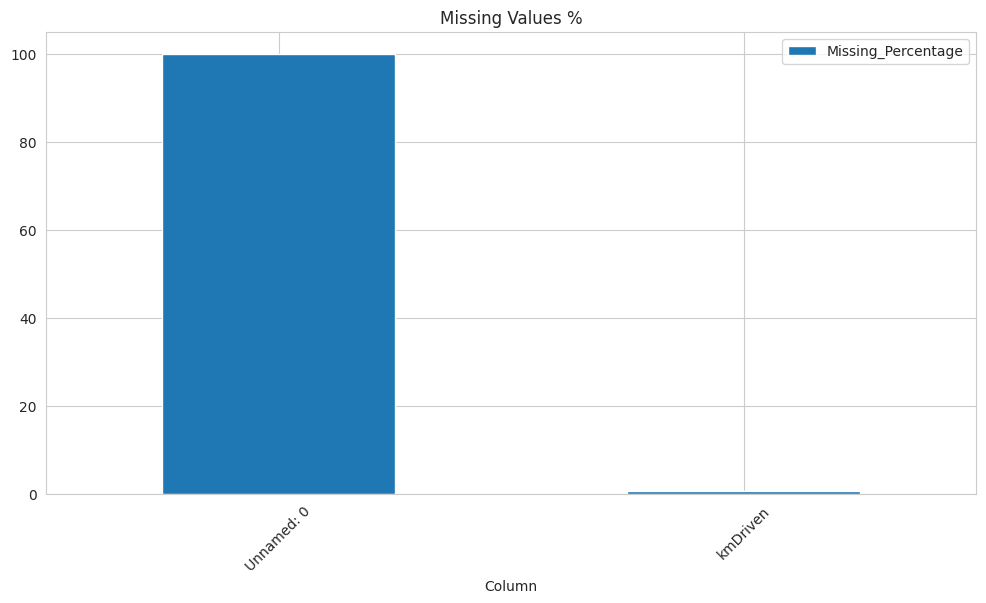


Duplicate rows: 997

Categorical columns:
['Brand', 'model', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice']

Numeric columns:
['Unnamed: 0', 'Year', 'Age']


In [ ]:
# ============================================================
# CELL 2: EXPLORATORY DATA ANALYSIS
# ============================================================

print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

display(df.describe(include='all'))

print("\nMissing values percentage")

missing = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum()/len(df))*100
})

display(missing)

plt.figure(figsize=(12,4))
missing[missing["Missing_Count"]>0].plot(
    x="Column",
    y="Missing_Percentage",
    kind="bar"
)
plt.title("Missing Values %")
plt.xticks(rotation=45)
plt.show()

print("\nDuplicate rows:", df.duplicated().sum())

print("\nCategorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

print("\nNumeric columns:")
print(df.select_dtypes(include=['int64','float64']).columns.tolist())

In [ ]:
# ============================================================
# CELL 3: DATA CLEANING
# ============================================================

df_clean = df.copy()

# Drop useless index column
if "Unnamed: 0" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Unnamed: 0"])

# Remove duplicates
df_clean = df_clean.drop_duplicates()

print("Dataset shape after removing duplicates:", df_clean.shape)

# Handle missing kmDriven
df_clean["kmDriven"] = df_clean["kmDriven"].fillna("0 km")

print("\nMissing values remaining:")
print(df_clean.isnull().sum())

Dataset shape after removing duplicates: (13996, 11)

Missing values remaining:
Brand           0
model           0
Year            0
Age             0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
PostedDate      0
AdditionInfo    0
AskPrice        0
dtype: int64


In [ ]:
# ============================================================
# CELL 4: DATA TYPE CLEANING
# ============================================================

def clean_price(x):
    if isinstance(x,str):
        x = x.replace("₹","")
        x = x.replace("_","")
        x = x.replace(",","")
        return float(x)
    return x

def clean_km(x):
    if isinstance(x,str):
        x = x.replace("km","")
        x = x.replace(",","")
        x = x.strip()
        return float(x)
    return x

df_clean["AskPrice"] = df_clean["AskPrice"].apply(clean_price)
df_clean["kmDriven"] = df_clean["kmDriven"].apply(clean_km)

# convert numeric safely
df_clean["Year"] = pd.to_numeric(df_clean["Year"], errors="coerce")
df_clean["Age"] = pd.to_numeric(df_clean["Age"], errors="coerce")

# drop rows where price couldn't convert
df_clean = df_clean.dropna(subset=["AskPrice"])

print("Updated data types")
print(df_clean.dtypes)

display(df_clean.head())

Updated data types
Brand            object
model            object
Year              int64
Age               int64
kmDriven        float64
Transmission     object
Owner            object
FuelType         object
PostedDate       object
AdditionInfo     object
AskPrice        float64
dtype: object


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,98000.0,Manual,second,Petrol,24-Nov,"Honda City v teck in mint condition, valid gen...",195000.0
1,Toyota,Innova,2009,15,190000.0,Manual,second,Diesel,24-Jul,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000.0
2,Volkswagen,VentoTest,2010,14,77246.0,Manual,first,Diesel,24-Nov,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999.0
3,Maruti Suzuki,Swift,2017,7,83500.0,Manual,second,Diesel,24-Nov,Maruti Suzuki Swift 2017 Diesel Good Condition,565000.0
4,Maruti Suzuki,Baleno,2019,5,45000.0,Automatic,first,Petrol,24-Nov,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000.0



Column: AskPrice
Outliers: 1393

Column: kmDriven
Outliers: 518

Column: Age
Outliers: 197

Column: Year
Outliers: 197


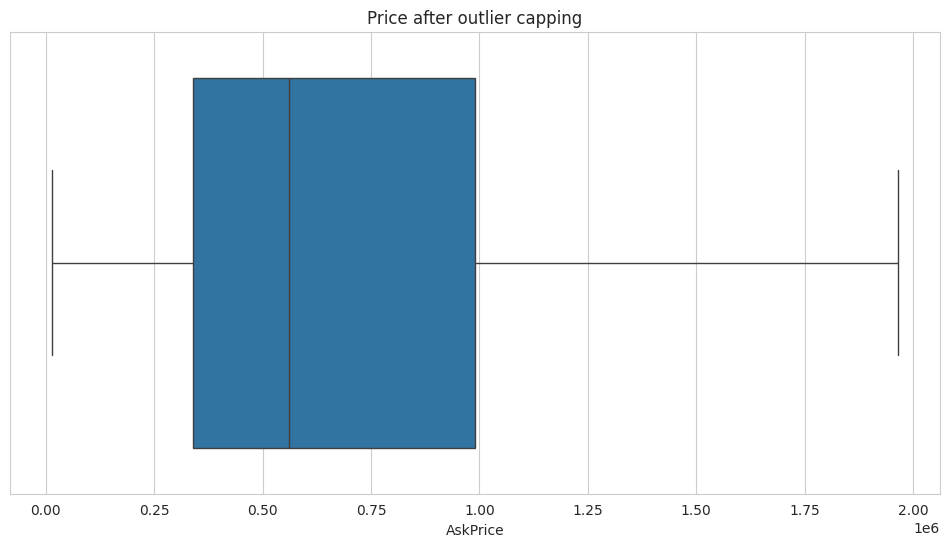

In [ ]:
# ============================================================
# CELL 5: OUTLIER DETECTION (IQR)
# ============================================================

cols = ["AskPrice","kmDriven","Age","Year"]

for col in cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]

    print("\nColumn:",col)
    print("Outliers:",len(outliers))

    df_clean[col] = df_clean[col].clip(lower,upper)

plt.figure()
sns.boxplot(x=df_clean["AskPrice"])
plt.title("Price after outlier capping")
plt.show()

In [ ]:
# ============================================================
# CELL 6: FEATURE ENCODING
# ============================================================

df_encoded = df_clean.copy()

cat_cols = ["Brand","model","Transmission","Owner","FuelType"]

df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=True)

X = df_encoded.drop("AskPrice",axis=1)
y = df_encoded["AskPrice"]

# Drop non-numeric columns like 'PostedDate' and 'AdditionInfo' before scaling
# These columns were not one-hot encoded and are not suitable for StandardScaler
X = X.drop(columns=["PostedDate", "AdditionInfo"], errors='ignore')

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature matrix shape:",X_scaled.shape)
print("Target shape:",y.shape)


Feature matrix shape: (13996, 485)
Target shape: (13996,)


In [ ]:
# ============================================================
# CELL 7: FEATURE ENGINEERING + ENCODING (FIXED)
# ============================================================

print("FEATURE ENGINEERING")
print("="*60)

df_fe = df_clean.copy()

# ---- Create new features ----

df_fe['Price_per_km'] = df_fe['AskPrice'] / (df_fe['kmDriven'] + 1)
df_fe['Price_per_year'] = df_fe['AskPrice'] / (df_fe['Age'] + 1)

# Age groups
df_fe['Age_group'] = pd.cut(
    df_fe['Age'],
    bins=[0,5,10,50],
    labels=['0-5_years','5-10_years','10+_years']
)

# Brand category
luxury_brands = ['BMW','Mercedes-Benz','Audi','Jaguar','Porsche']

df_fe['Brand_category'] = df_fe['Brand'].apply(
    lambda x: 'Luxury' if x in luxury_brands else 'Regular'
)

print("\nNew features created:")
print(df_fe[['Price_per_km','Price_per_year','Age_group','Brand_category']].head())


# ---------------------------------------------------
# DROP TEXT COLUMNS THAT BREAK ML MODELS
# ---------------------------------------------------

drop_cols = ['PostedDate','AdditionInfo']

for col in drop_cols:
    if col in df_fe.columns:
        df_fe = df_fe.drop(columns=[col])


# ---------------------------------------------------
# ONE HOT ENCODING
# ---------------------------------------------------

categorical_cols = [
    'Brand','model','Transmission','Owner','FuelType',
    'Age_group','Brand_category'
]

categorical_cols = [c for c in categorical_cols if c in df_fe.columns]

df_fe = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)

print("\nDataset after encoding:", df_fe.shape)


# ---------------------------------------------------
# SPLIT FEATURES / TARGET
# ---------------------------------------------------

X_fe = df_fe.drop('AskPrice', axis=1)
y_fe = df_fe['AskPrice']


# ---------------------------------------------------
# FEATURE SCALING
# ---------------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_fe_scaled = scaler.fit_transform(X_fe)
X_fe_scaled = pd.DataFrame(X_fe_scaled, columns=X_fe.columns)

print("\nFinal feature matrix shape:", X_fe_scaled.shape)
print("Total features:", X_fe_scaled.shape[1])

FEATURE ENGINEERING

New features created:
   Price_per_km  Price_per_year   Age_group Brand_category
0      1.989776    10540.540541   10+_years        Regular
1      2.478135    23437.500000   10+_years        Regular
2      2.394902    12333.266667   10+_years        Regular
3      6.766386    70625.000000  5-10_years        Regular
4     15.221884   114166.666667   0-5_years        Regular

Dataset after encoding: (13996, 491)

Final feature matrix shape: (13996, 490)
Total features: 490


CORRELATION ANALYSIS

Top 15 features correlated with price:
AskPrice                1.000000
Price_per_year          0.657295
Year                    0.495220
Brand_Mercedes-Benz     0.319254
Brand_Toyota            0.259788
Brand_BMW               0.256843
model_Innova Crysta     0.226344
model_Fortuner          0.209795
Brand_Land Rover        0.168065
Brand_Audi              0.167326
model_Endeavour         0.153936
Brand_Kia               0.129767
model_C-Class           0.123126
model_5 Series          0.122611
model_Innova Hycross    0.120445
Name: AskPrice, dtype: float64


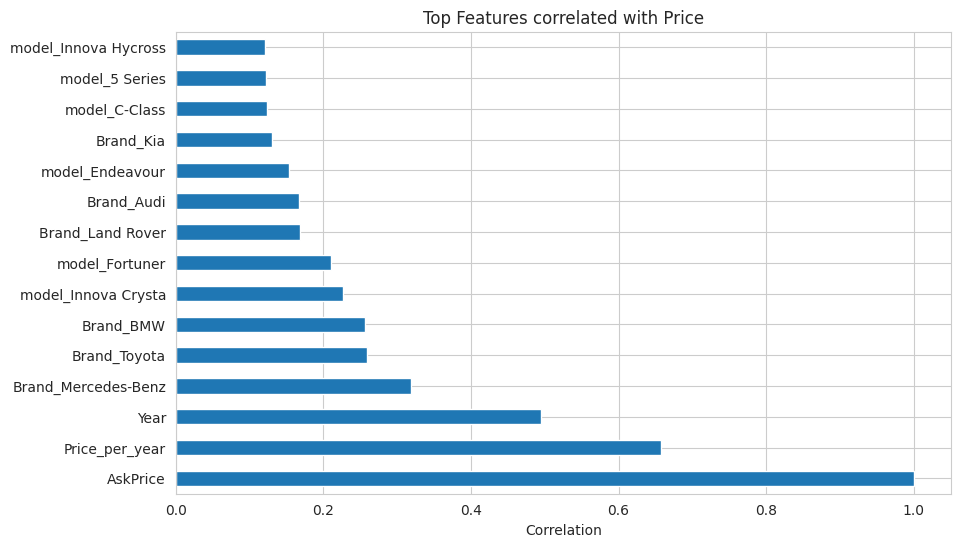

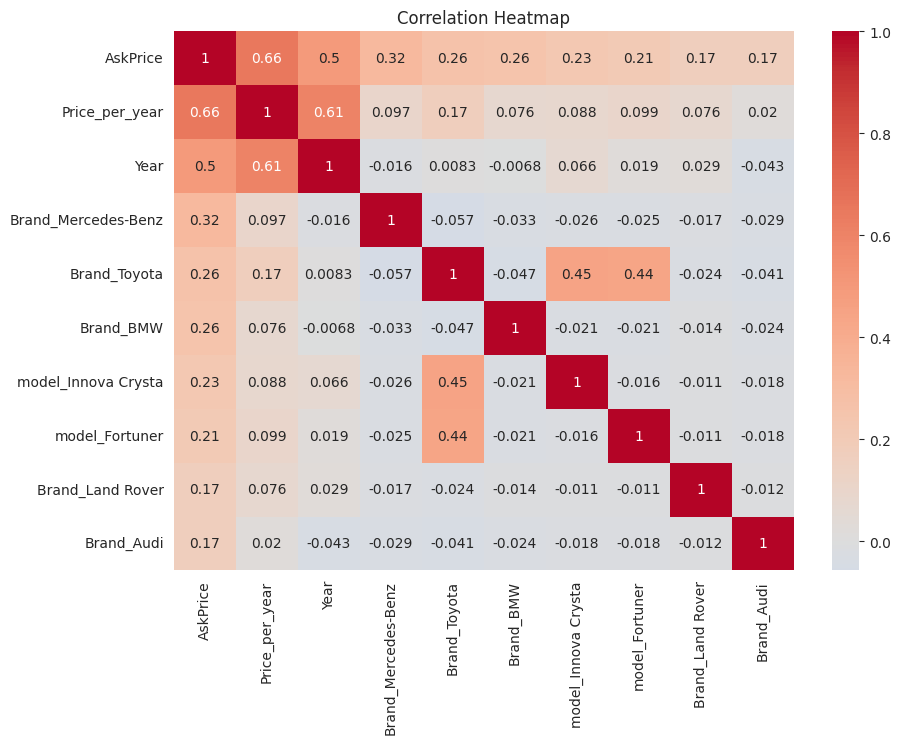

In [ ]:
# ============================================================
# CELL 8: CORRELATION ANALYSIS
# ============================================================

print("CORRELATION ANALYSIS")
print("="*60)

df_analysis = pd.concat(
    [X_fe_scaled, y_fe.reset_index(drop=True)],
    axis=1
)

correlations = df_analysis.corr()['AskPrice'].sort_values(ascending=False)

print("\nTop 15 features correlated with price:")
print(correlations.head(15))

plt.figure(figsize=(10,6))
correlations.head(15).plot(kind='barh')
plt.title("Top Features correlated with Price")
plt.xlabel("Correlation")
plt.show()


# Heatmap of important features

top_features = correlations.head(10).index.tolist()

plt.figure(figsize=(10,7))
sns.heatmap(
    df_analysis[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# ============================================================
# CELL 8: DESCRIPTIVE STATISTICS
# ============================================================

print("DESCRIPTIVE STATISTICAL ANALYSIS")
print("="*60)

# Numerical features used for statistical analysis
key_features = ['AskPrice','Age','kmDriven','Year']
key_features = [f for f in key_features if f in df_clean.columns]

desc_stats = pd.DataFrame({
    'Feature': key_features,
    'Mean': [df_clean[f].mean() for f in key_features],
    'Median': [df_clean[f].median() for f in key_features],
    'Mode': [df_clean[f].mode()[0] for f in key_features],
    'Std_Dev': [df_clean[f].std() for f in key_features],
    'Min': [df_clean[f].min() for f in key_features],
    'Max': [df_clean[f].max() for f in key_features],
    'Q1': [df_clean[f].quantile(0.25) for f in key_features],
    'Q3': [df_clean[f].quantile(0.75) for f in key_features],
    'IQR': [df_clean[f].quantile(0.75) - df_clean[f].quantile(0.25) for f in key_features],
    'Skewness': [df_clean[f].skew() for f in key_features],
    'Kurtosis': [df_clean[f].kurtosis() for f in key_features]
})

print("\nDESCRIPTIVE STATISTICS TABLE")
display(desc_stats)


print("\nPERCENTILES")
for feature in key_features:
    print("\n",feature)
    for p in [10,25,50,75,90]:
        value = df_clean[feature].quantile(p/100)
        print(f"{p}th percentile: {value:,.2f}")

DESCRIPTIVE STATISTICAL ANALYSIS

DESCRIPTIVE STATISTICS TABLE


,Feature,Mean,Median,Mode,Std_Dev,Min,Max,Q1,Q3,IQR,Skewness,Kurtosis
0,AskPrice,752573.668477,560000.0,1965000.0,564719.069442,15000.0,1965000.0,340000.00,990000.00,650000.0,1.049561,-0.087620
1,Age,7.611853,7.0,7.0,4.010692,0.0,17.5,5.00,10.00,5.0,0.303778,-0.449417
2,kmDriven,67312.818377,65653.5,151322.5,35436.183120,0.0,151322.5,43333.75,86529.25,43195.5,0.404429,-0.029086
3,Year,2016.388147,2017.0,2017.0,4.010692,2006.5,2024.0,2014.00,2019.00,5.0,-0.303778,-0.449417



PERCENTILES

 AskPrice
10th percentile: 199,999.00
25th percentile: 340,000.00
50th percentile: 560,000.00
75th percentile: 990,000.00
90th percentile: 1,950,500.00

 Age
10th percentile: 2.00
25th percentile: 5.00
50th percentile: 7.00
75th percentile: 10.00
90th percentile: 13.00

 kmDriven
10th percentile: 21,000.00
25th percentile: 43,333.75
50th percentile: 65,653.50
75th percentile: 86,529.25
90th percentile: 115,000.00

 Year
10th percentile: 2,011.00
25th percentile: 2,014.00
50th percentile: 2,017.00
75th percentile: 2,019.00
90th percentile: 2,022.00


PROBABILITY DISTRIBUTION ANALYSIS
AskPrice → p-value = 0.000000
Age → p-value = 0.000000
kmDriven → p-value = 0.000000
Year → p-value = 0.000000


,Feature,Statistic,P_Value,Normally_Distributed
0,AskPrice,0.848700,1.964771e-56,No
1,Age,0.979451,2.626918e-26,No
2,kmDriven,0.974701,6.823486e-29,No
3,Year,0.978206,5.023672e-27,No


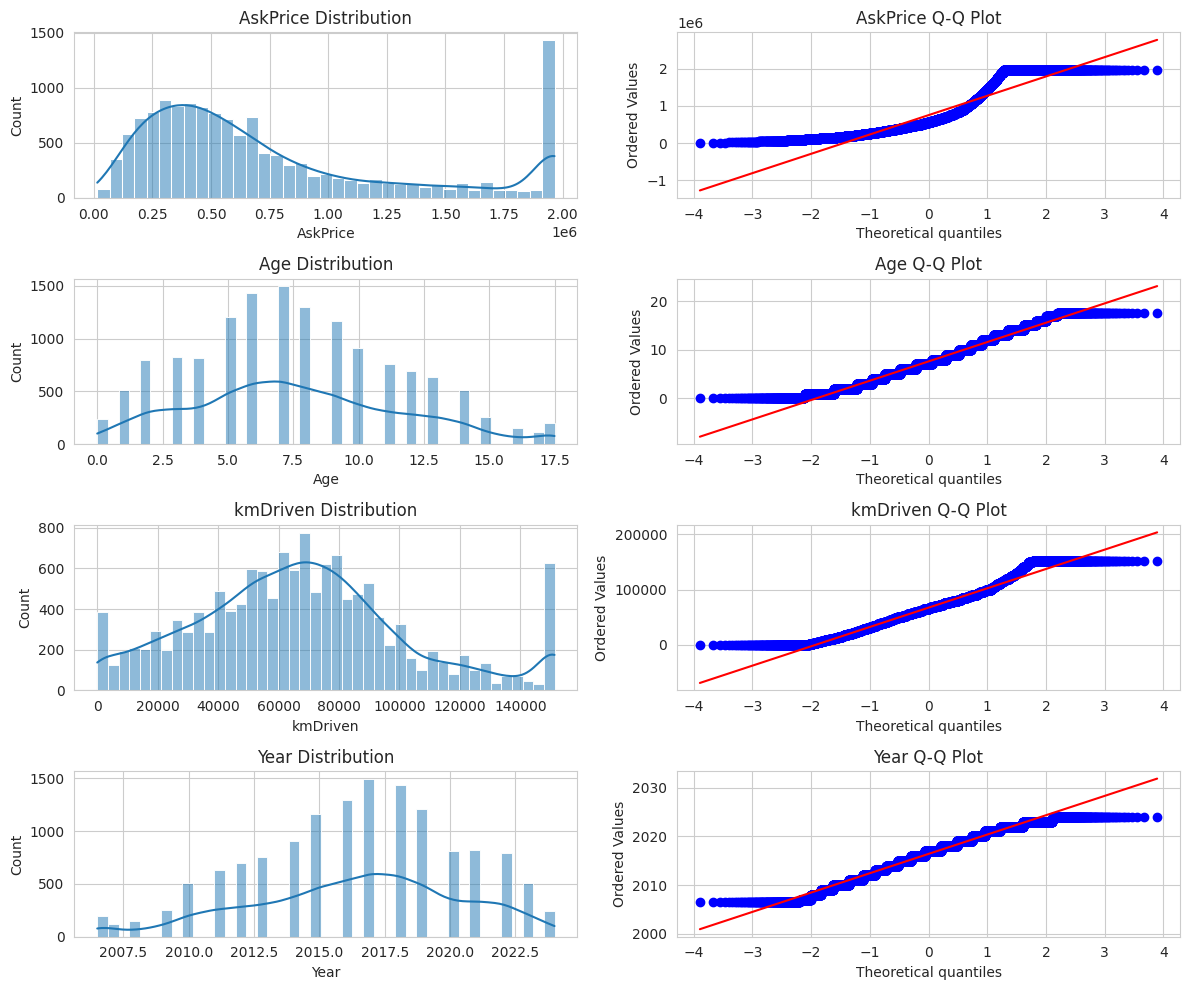

In [ ]:
# ============================================================
# CELL 9: DISTRIBUTION ANALYSIS
# ============================================================

print("PROBABILITY DISTRIBUTION ANALYSIS")
print("="*60)

normality_results = []

for feature in key_features:

    data = df_clean[feature].dropna()

    stat,p_value = stats.shapiro(data.sample(min(5000,len(data))))

    normality_results.append({
        "Feature":feature,
        "Statistic":stat,
        "P_Value":p_value,
        "Normally_Distributed":"Yes" if p_value>0.05 else "No"
    })

    print(f"{feature} → p-value = {p_value:.6f}")

normality_df = pd.DataFrame(normality_results)

display(normality_df)


# Visualizations
fig,axes = plt.subplots(len(key_features),2,figsize=(12,10))

for i,feature in enumerate(key_features):

    data = df_clean[feature].dropna()

    sns.histplot(data,kde=True,ax=axes[i,0])
    axes[i,0].set_title(f"{feature} Distribution")

    stats.probplot(data,dist="norm",plot=axes[i,1])
    axes[i,1].set_title(f"{feature} Q-Q Plot")

plt.tight_layout()
plt.show()

CORRELATION ANALYSIS

Correlation Matrix


,AskPrice,Age,kmDriven,Year
AskPrice,1.000000,-0.495220,-0.192746,0.495220
Age,-0.495220,1.000000,0.438897,-1.000000
kmDriven,-0.192746,0.438897,1.000000,-0.438897
Year,0.495220,-1.000000,-0.438897,1.000000


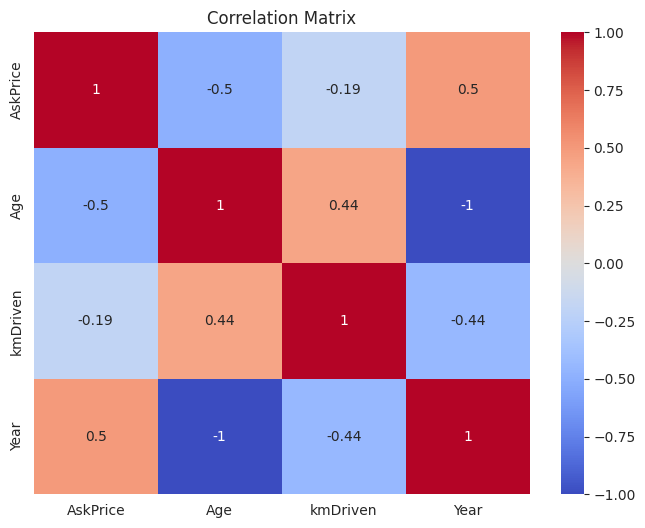


Spearman Correlation


,AskPrice,Age,kmDriven,Year
AskPrice,1.000000,-0.595054,-0.222584,0.595054
Age,-0.595054,1.000000,0.479463,-1.000000
kmDriven,-0.222584,0.479463,1.000000,-0.479463
Year,0.595054,-1.000000,-0.479463,1.000000



Covariance Matrix


,AskPrice,Age,kmDriven,Year
AskPrice,3.189076e+11,-1.121631e+06,-3.857135e+09,1.121631e+06
Age,-1.121631e+06,1.608565e+01,6.237767e+04,-1.608565e+01
kmDriven,-3.857135e+09,6.237767e+04,1.255723e+09,-6.237767e+04
Year,1.121631e+06,-1.608565e+01,-6.237767e+04,1.608565e+01


In [ ]:
# ============================================================
# CELL 10: CORRELATION & COVARIANCE ANALYSIS
# ============================================================

print("CORRELATION ANALYSIS")
print("="*60)

corr_matrix = df_clean[key_features].corr()

print("\nCorrelation Matrix")
display(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",center=0)
plt.title("Correlation Matrix")
plt.show()


print("\nSpearman Correlation")
spearman_corr = df_clean[key_features].corr(method="spearman")
display(spearman_corr)


print("\nCovariance Matrix")
cov_matrix = df_clean[key_features].cov()
display(cov_matrix)

In [ ]:
# ============================================================
# CELL 11: HYPOTHESIS TESTING
# ============================================================

print("HYPOTHESIS TESTING")
print("="*60)

# Petrol vs Diesel
petrol = df_clean[df_clean["FuelType"]=="Petrol"]["AskPrice"]
diesel = df_clean[df_clean["FuelType"]=="Diesel"]["AskPrice"]

t_stat,p_value = stats.ttest_ind(petrol,diesel)

print("\nPetrol vs Diesel Price")
print("t-statistic:",t_stat)
print("p-value:",p_value)


# Manual vs Automatic
manual = df_clean[df_clean["Transmission"]=="Manual"]["AskPrice"]
auto = df_clean[df_clean["Transmission"]=="Automatic"]["AskPrice"]

t_stat2,p_value2 = stats.ttest_ind(manual,auto)

print("\nManual vs Automatic Price")
print("t-statistic:",t_stat2)
print("p-value:",p_value2)


# ANOVA Fuel Types
fuel_groups = [group["AskPrice"].values for name,group in df_clean.groupby("FuelType")]

f_stat,p_val = stats.f_oneway(*fuel_groups)

print("\nANOVA FuelType")
print("F-statistic:",f_stat)
print("p-value:",p_val)


# ANOVA Transmission
trans_groups = [group["AskPrice"].values for name,group in df_clean.groupby("Transmission")]

f_stat2,p_val2 = stats.f_oneway(*trans_groups)

print("\nANOVA Transmission")
print("F-statistic:",f_stat2)
print("p-value:",p_val2)

HYPOTHESIS TESTING

Petrol vs Diesel Price
t-statistic: -35.65268381398248
p-value: 1.53811001845908e-262

Manual vs Automatic Price
t-statistic: -52.874624913633696
p-value: 0.0

ANOVA FuelType
F-statistic: 964.8731440950843
p-value: 0.0

ANOVA Transmission
F-statistic: 2795.725959757452
p-value: 0.0


BOX PLOT ANALYSIS


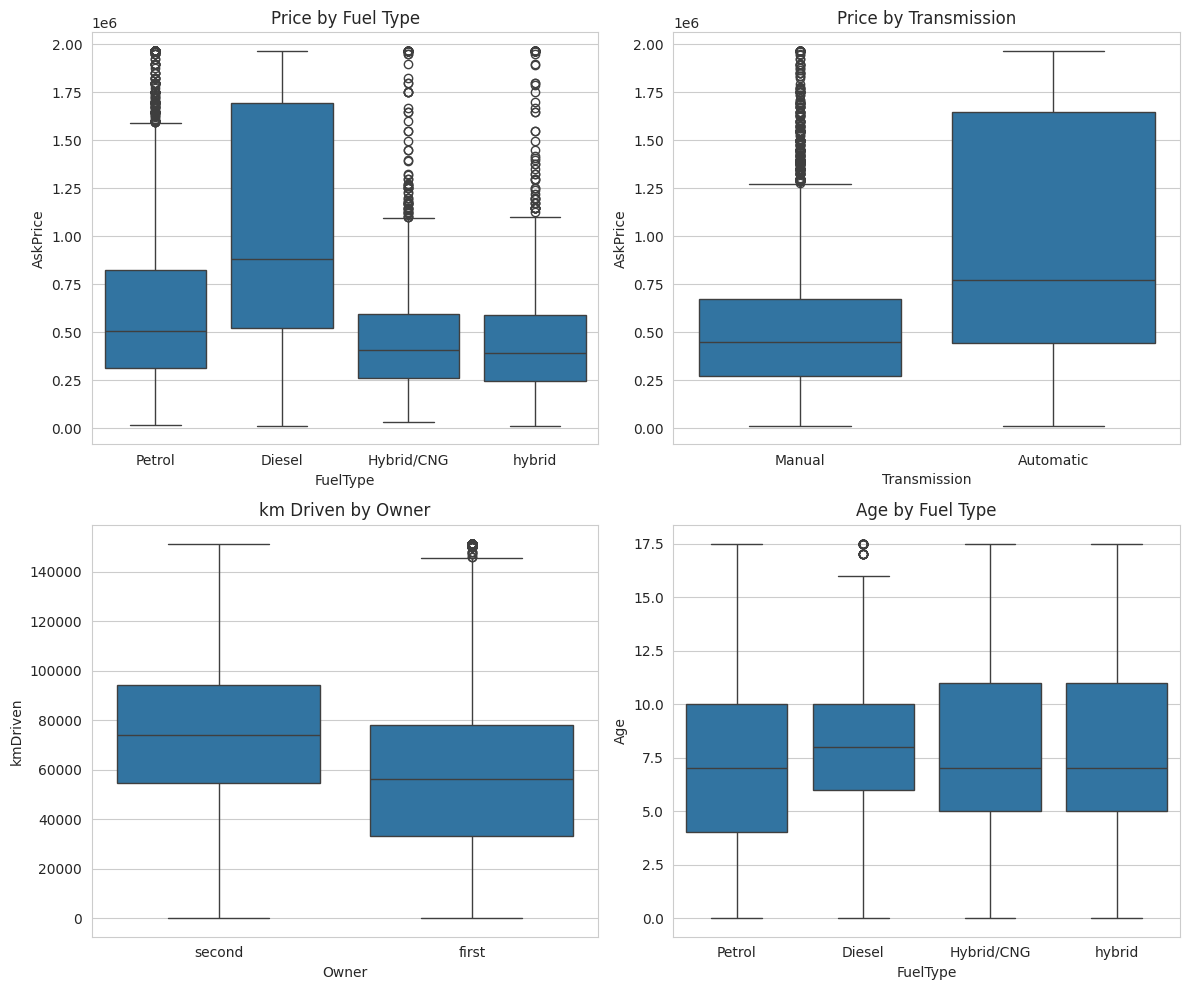


Price statistics by FuelType


,count,mean,std,min,25%,50%,75%,max
FuelType,,,,,,,,
Diesel,4846.0,1.058496e+06,616016.985320,15000.0,525000.0,882500.0,1695000.0,1965000.0
Hybrid/CNG,1821.0,4.920122e+05,364438.070910,32000.0,260000.0,410000.0,595000.0,1965000.0
Petrol,5398.0,6.640602e+05,502456.445268,18500.0,315000.0,507000.0,825000.0,1965000.0
hybrid,1931.0,4.779893e+05,363659.274469,15000.0,245000.0,395000.0,590000.0,1965000.0



Price statistics by Transmission


,count,mean,std,min,25%,50%,75%,max
Transmission,,,,,,,,
Automatic,6907.0,986021.687853,643168.522858,15000.0,445000.0,775000.0,1650000.0,1965000.0
Manual,7089.0,525119.095218,348967.661813,15000.0,275000.0,450000.0,675000.0,1965000.0


In [ ]:
# ============================================================
# CELL 12: BOX PLOTS
# ============================================================

print("BOX PLOT ANALYSIS")
print("="*60)

fig,axes = plt.subplots(2,2,figsize=(12,10))

sns.boxplot(data=df_clean,x="FuelType",y="AskPrice",ax=axes[0,0])
axes[0,0].set_title("Price by Fuel Type")

sns.boxplot(data=df_clean,x="Transmission",y="AskPrice",ax=axes[0,1])
axes[0,1].set_title("Price by Transmission")

sns.boxplot(data=df_clean,x="Owner",y="kmDriven",ax=axes[1,0])
axes[1,0].set_title("km Driven by Owner")

sns.boxplot(data=df_clean,x="FuelType",y="Age",ax=axes[1,1])
axes[1,1].set_title("Age by Fuel Type")

plt.tight_layout()
plt.show()


print("\nPrice statistics by FuelType")
display(df_clean.groupby("FuelType")["AskPrice"].describe())

print("\nPrice statistics by Transmission")
display(df_clean.groupby("Transmission")["AskPrice"].describe())

In [ ]:
# ============================================================
# CELL 13: DATA PREPARATION FOR MODELING
# ============================================================

print("DATA PREPARATION FOR MODELING")
print("="*60)

# Use engineered + scaled features
X = X_fe_scaled.copy()
y = y_fe.copy()

# Binary classification target
y_binary = (y > y.median()).astype(int)

# Train-test split (regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train-test split (classification)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

print("\nFeature matrix shape:", X_train.shape)
print("Target shape:", y_train.shape)

print("\nClassification target distribution")
print("Affordable (0):", (y_train_bin==0).sum())
print("Expensive (1):", (y_train_bin==1).sum())

DATA PREPARATION FOR MODELING
Training set size: 11196
Test set size: 2800

Feature matrix shape: (11196, 490)
Target shape: (11196,)

Classification target distribution
Affordable (0): 5635
Expensive (1): 5561


LINEAR REGRESSION
Training RMSE: 163630.1045055392
Testing RMSE: 183911.76013126533
Training MAE: 110099.79302280738
Testing MAE: 118859.6993776127
Training R2: 0.9151502129212865
Testing R2: 0.898134478785945


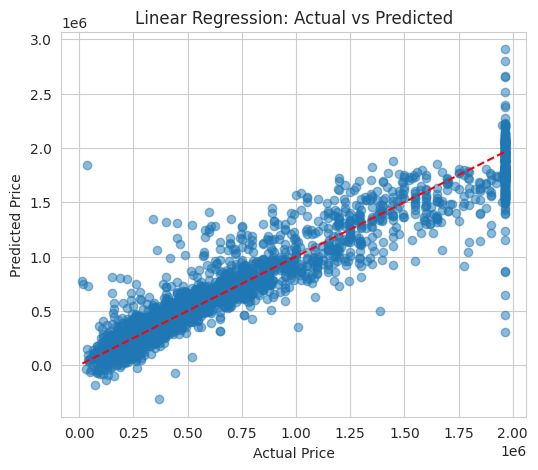

In [ ]:
# ============================================================
# CELL 14: LINEAR REGRESSION
# ============================================================

print("LINEAR REGRESSION")
print("="*60)

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

print("Training MAE:", train_mae)
print("Testing MAE:", test_mae)

print("Training R2:", train_r2)
print("Testing R2:", test_r2)


# Visualization
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

LOGISTIC REGRESSION
Training Accuracy: 0.9575741336191497
Testing Accuracy: 0.955
Precision: 0.9568965517241379
Recall: 0.9527896995708155
F1 Score: 0.9548387096774194
ROC AUC: 0.9908657976853014


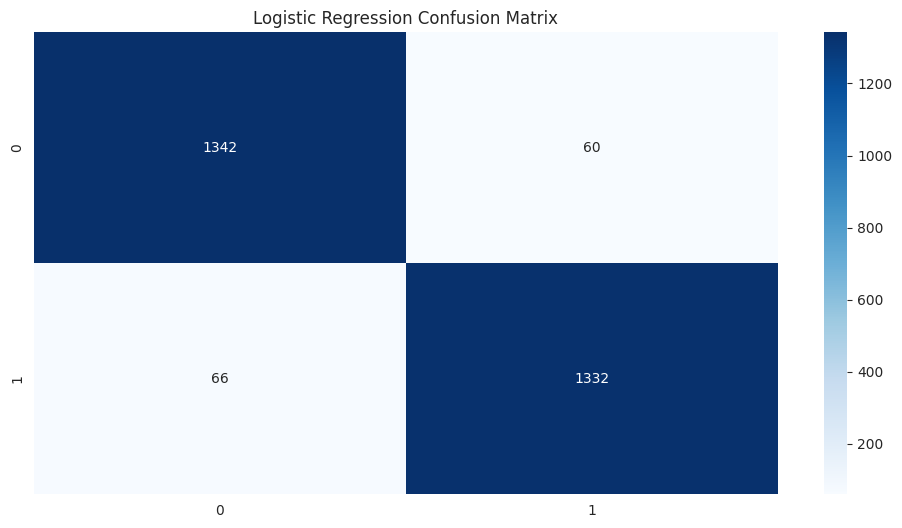

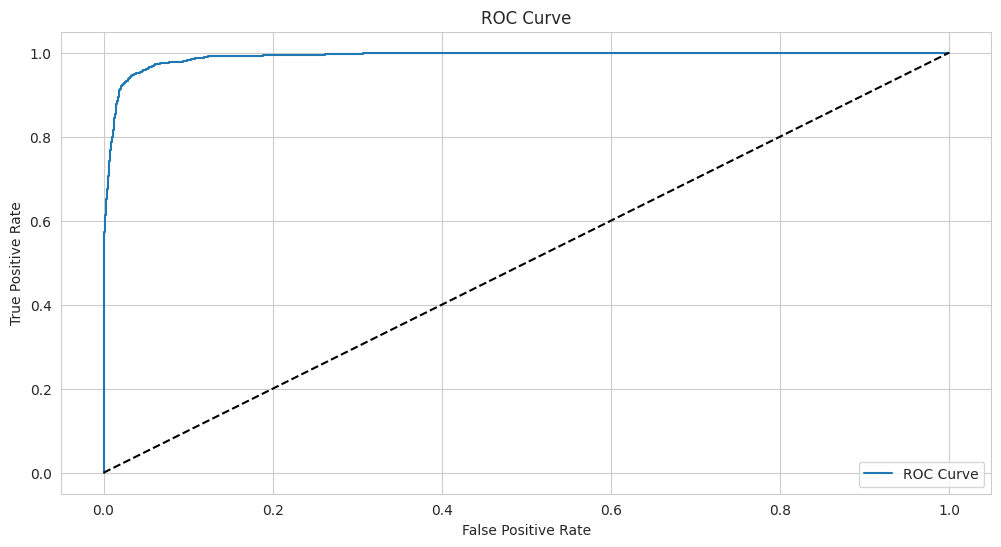

In [ ]:
# ============================================================
# CELL 15: LOGISTIC REGRESSION
# ============================================================

print("LOGISTIC REGRESSION")
print("="*60)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_bin, y_train_bin)

y_train_pred = log_model.predict(X_train_bin)
y_test_pred = log_model.predict(X_test_bin)

y_prob = log_model.predict_proba(X_test_bin)[:,1]

# Metrics
train_acc = accuracy_score(y_train_bin, y_train_pred)
test_acc = accuracy_score(y_test_bin, y_test_pred)

precision = precision_score(y_test_bin, y_test_pred)
recall = recall_score(y_test_bin, y_test_pred)
f1 = f1_score(y_test_bin, y_test_pred)

fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
roc_auc = auc(fpr, tpr)

print("Training Accuracy:",train_acc)
print("Testing Accuracy:",test_acc)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("ROC AUC:",roc_auc)

# Confusion matrix
cm = confusion_matrix(y_test_bin, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()


# ROC Curve
plt.plot(fpr,tpr,label="ROC Curve")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

NAIVE BAYES CLASSIFIER
Training Accuracy: 0.7685780635941407
Testing Accuracy: 0.7696428571428572
Precision: 0.9759797724399494
Recall: 0.5522174535050072
F1 Score: 0.7053449063499315


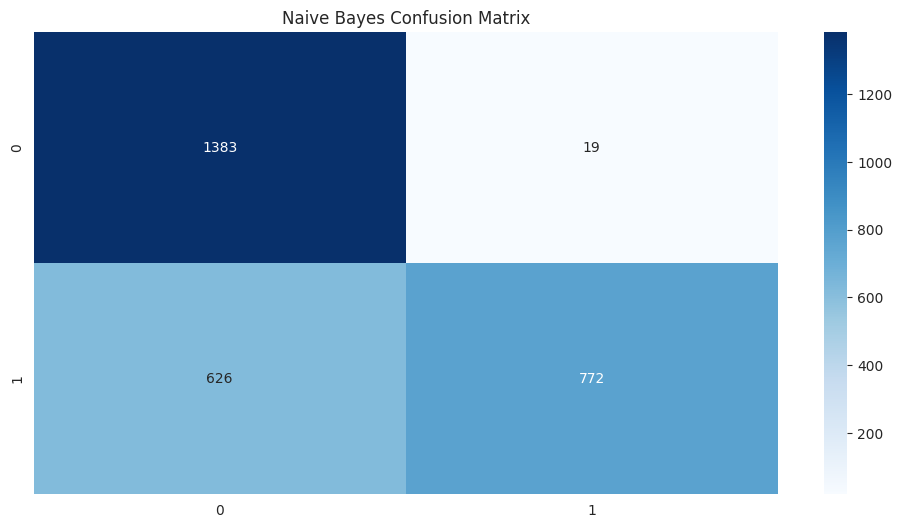

In [ ]:
# ============================================================
# CELL 16: NAIVE BAYES
# ============================================================

print("NAIVE BAYES CLASSIFIER")
print("="*60)

nb_model = GaussianNB()

nb_model.fit(X_train_bin, y_train_bin)

y_train_pred = nb_model.predict(X_train_bin)
y_test_pred = nb_model.predict(X_test_bin)

train_acc = accuracy_score(y_train_bin, y_train_pred)
test_acc = accuracy_score(y_test_bin, y_test_pred)

precision = precision_score(y_test_bin, y_test_pred)
recall = recall_score(y_test_bin, y_test_pred)
f1 = f1_score(y_test_bin, y_test_pred)

cm = confusion_matrix(y_test_bin, y_test_pred)

print("Training Accuracy:",train_acc)
print("Testing Accuracy:",test_acc)

print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

sns.heatmap(cm,annot=True,fmt='d',cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

DECISION TREE CLASSIFIER
Training Accuracy: 0.994908896034298
Testing Accuracy: 0.9896428571428572
Precision: 0.9885795860099929
Recall: 0.9907010014306151
F1 Score: 0.9896391568417292

Top 10 Important Features
                    Feature  Importance
4            Price_per_year    0.795768
1                       Age    0.103383
0                      Year    0.050734
489  Brand_category_Regular    0.014966
30      Brand_Maruti Suzuki    0.009521
255              model_KWID    0.004518
487    Age_group_5-10_years    0.004175
3              Price_per_km    0.003008
245            model_Innova    0.002791
411            model_Triber    0.001873


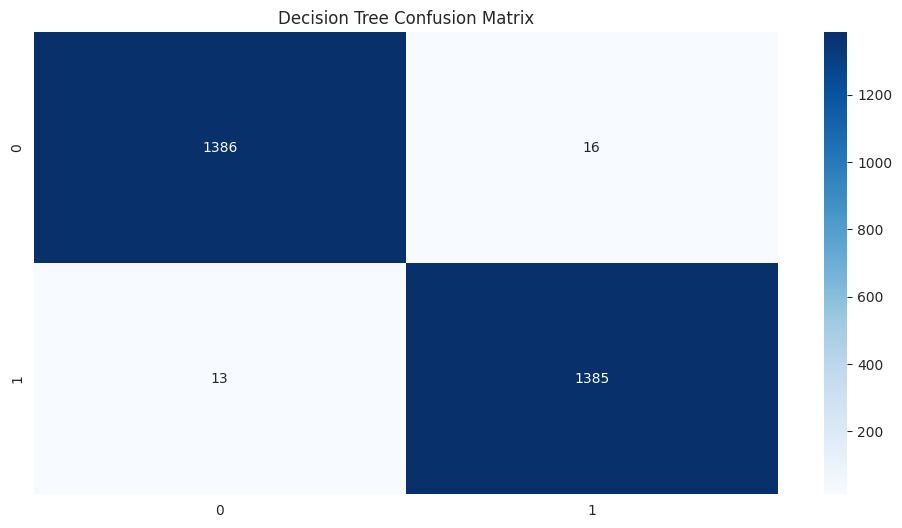

In [ ]:
# ============================================================
# CELL 17: DECISION TREE CLASSIFIER
# ============================================================

print("DECISION TREE CLASSIFIER")
print("="*60)

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    random_state=42
)

dt_model.fit(X_train_bin, y_train_bin)

y_train_pred_dt = dt_model.predict(X_train_bin)
y_test_pred_dt = dt_model.predict(X_test_bin)

train_acc_dt = accuracy_score(y_train_bin, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test_bin, y_test_pred_dt)

precision_dt = precision_score(y_test_bin, y_test_pred_dt)
recall_dt = recall_score(y_test_bin, y_test_pred_dt)
f1_dt = f1_score(y_test_bin, y_test_pred_dt)

cm_dt = confusion_matrix(y_test_bin, y_test_pred_dt)

print("Training Accuracy:",train_acc_dt)
print("Testing Accuracy:",test_acc_dt)
print("Precision:",precision_dt)
print("Recall:",recall_dt)
print("F1 Score:",f1_dt)

# Feature importance
feat_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":dt_model.feature_importances_
}).sort_values("Importance",ascending=False)

print("\nTop 10 Important Features")
print(feat_importance.head(10))

# Confusion matrix
sns.heatmap(cm_dt,annot=True,fmt='d',cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

K NEAREST NEIGHBORS
K = 3 CV Score = 0.904608163721049
K = 5 CV Score = 0.902285738212212
K = 7 CV Score = 0.8988918442544502
K = 9 CV Score = 0.8927291759714159
K = 11 CV Score = 0.8920150497671153

Best K: 3
Training Accuracy: 0.9496248660235799
Testing Accuracy: 0.9132142857142858
Precision: 0.9151689432063264
Recall: 0.9105865522174535
F1 Score: 0.9128719971315884


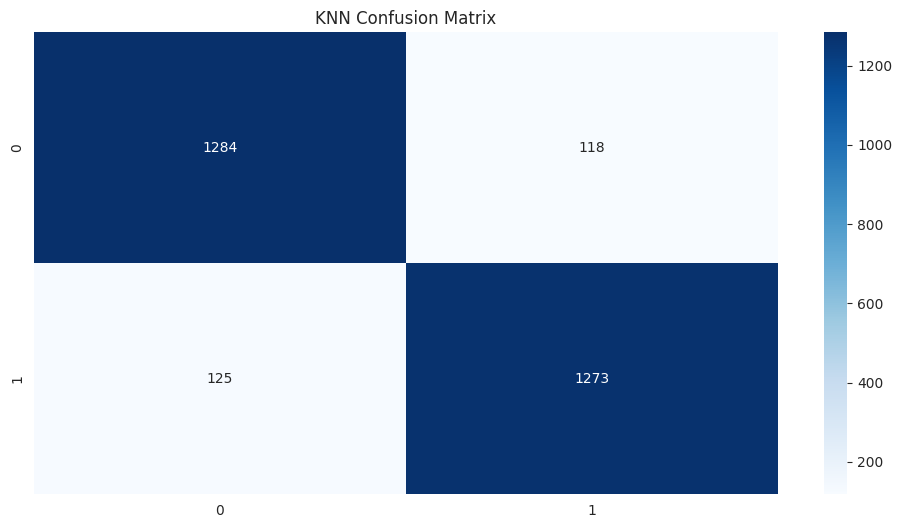

In [ ]:
# ============================================================
# CELL 18: KNN CLASSIFIER
# ============================================================

print("K NEAREST NEIGHBORS")
print("="*60)

k_values = [3,5,7,9,11]

cv_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X_train_bin, y_train_bin, cv=5)

    cv_scores.append(scores.mean())

    print("K =",k,"CV Score =",scores.mean())

best_k = k_values[cv_scores.index(max(cv_scores))]

print("\nBest K:",best_k)

knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model.fit(X_train_bin,y_train_bin)

y_train_pred_knn = knn_model.predict(X_train_bin)
y_test_pred_knn = knn_model.predict(X_test_bin)

train_acc_knn = accuracy_score(y_train_bin,y_train_pred_knn)
test_acc_knn = accuracy_score(y_test_bin,y_test_pred_knn)

precision_knn = precision_score(y_test_bin,y_test_pred_knn)
recall_knn = recall_score(y_test_bin,y_test_pred_knn)
f1_knn = f1_score(y_test_bin,y_test_pred_knn)

cm_knn = confusion_matrix(y_test_bin,y_test_pred_knn)

print("Training Accuracy:",train_acc_knn)
print("Testing Accuracy:",test_acc_knn)
print("Precision:",precision_knn)
print("Recall:",recall_knn)
print("F1 Score:",f1_knn)

sns.heatmap(cm_knn,annot=True,fmt='d',cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()

SUPPORT VECTOR MACHINE
C = 0.1 CV Score = 0.8720075527978052
C = 1 CV Score = 0.9113073438397243
C = 10 CV Score = 0.9252407803228483

Best C: 10
Training Accuracy: 0.94140764558771
Testing Accuracy: 0.9371428571428572
Precision: 0.9290730337078652
Recall: 0.9463519313304721
F1 Score: 0.9376328844790929


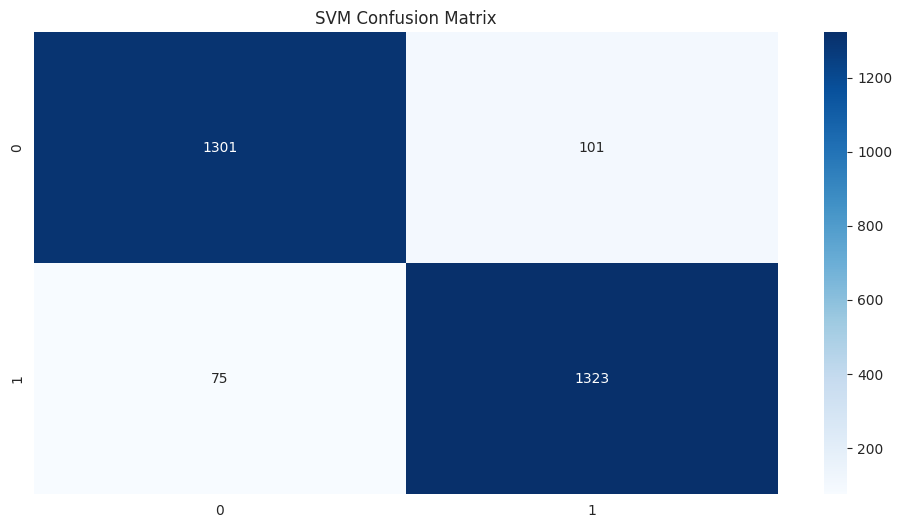

In [ ]:
# ============================================================
# CELL 19: SVM CLASSIFIER
# ============================================================

print("SUPPORT VECTOR MACHINE")
print("="*60)

C_values = [0.1,1,10]

best_score = 0
best_C = 1

for C in C_values:

    svm = SVC(kernel="rbf",C=C)

    scores = cross_val_score(svm,X_train_bin,y_train_bin,cv=5)

    mean_score = scores.mean()

    print("C =",C,"CV Score =",mean_score)

    if mean_score > best_score:
        best_score = mean_score
        best_C = C

print("\nBest C:",best_C)

svm_model = SVC(kernel="rbf",C=best_C)

svm_model.fit(X_train_bin,y_train_bin)

y_train_pred_svm = svm_model.predict(X_train_bin)
y_test_pred_svm = svm_model.predict(X_test_bin)

train_acc_svm = accuracy_score(y_train_bin,y_train_pred_svm)
test_acc_svm = accuracy_score(y_test_bin,y_test_pred_svm)

precision_svm = precision_score(y_test_bin,y_test_pred_svm)
recall_svm = recall_score(y_test_bin,y_test_pred_svm)
f1_svm = f1_score(y_test_bin,y_test_pred_svm)

cm_svm = confusion_matrix(y_test_bin,y_test_pred_svm)

print("Training Accuracy:",train_acc_svm)
print("Testing Accuracy:",test_acc_svm)
print("Precision:",precision_svm)
print("Recall:",recall_svm)
print("F1 Score:",f1_svm)

sns.heatmap(cm_svm,annot=True,fmt='d',cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1
2,Decision Tree,0.989643,0.988580,0.990701,0.989639
4,SVM,0.937143,0.929073,0.946352,0.937633
3,KNN,0.913214,0.915169,0.910587,0.912872
0,Logistic Regression,0.769643,0.975980,0.552217,0.705345
1,Naive Bayes,0.769643,0.975980,0.552217,0.705345


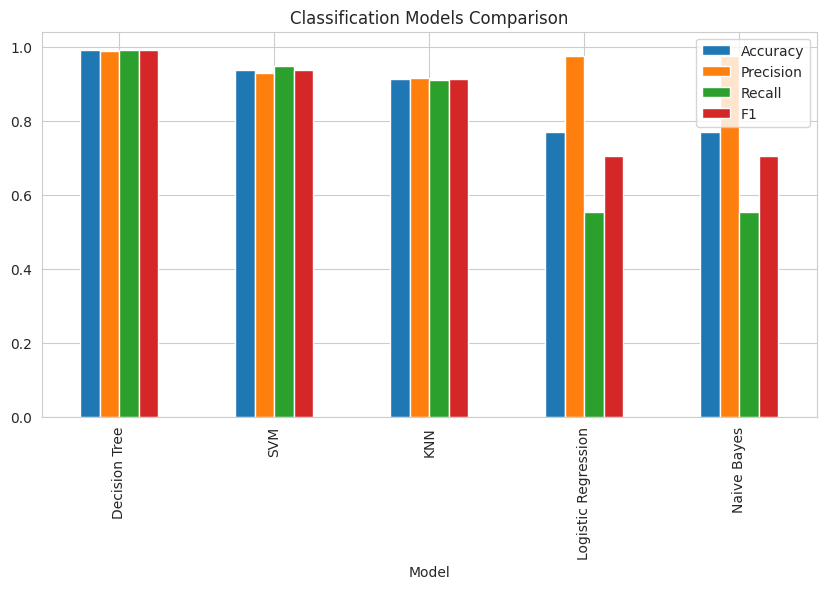

In [ ]:
# ============================================================
# CELL 20: CLASSIFICATION MODELS COMPARISON
# ============================================================

print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({

"Model":[
"Logistic Regression",
"Naive Bayes",
"Decision Tree",
"KNN",
"SVM"
],

"Accuracy":[
test_acc,
test_acc,
test_acc_dt,
test_acc_knn,
test_acc_svm
],

"Precision":[
precision,
precision,
precision_dt,
precision_knn,
precision_svm
],

"Recall":[
recall,
recall,
recall_dt,
recall_knn,
recall_svm
],

"F1":[
f1,
f1,
f1_dt,
f1_knn,
f1_svm
]

})

comparison_df = comparison_df.sort_values("F1",ascending=False)

display(comparison_df)

comparison_df.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Classification Models Comparison")
plt.show()

RANDOM FOREST CLASSIFIER
Training Accuracy: 0.9648088603072525
Testing Accuracy: 0.9657142857142857
Precision: 0.9584507042253522
Recall: 0.9735336194563662
F1 Score: 0.9659332860184529

Top 10 Important Features
                    Feature  Importance
4            Price_per_year    0.338082
3              Price_per_km    0.170377
1                       Age    0.076460
0                      Year    0.061496
488     Age_group_10+_years    0.035372
489  Brand_category_Regular    0.029116
2                  kmDriven    0.027799
30      Brand_Maruti Suzuki    0.022730
482     Transmission_Manual    0.019002
483            Owner_second    0.011222


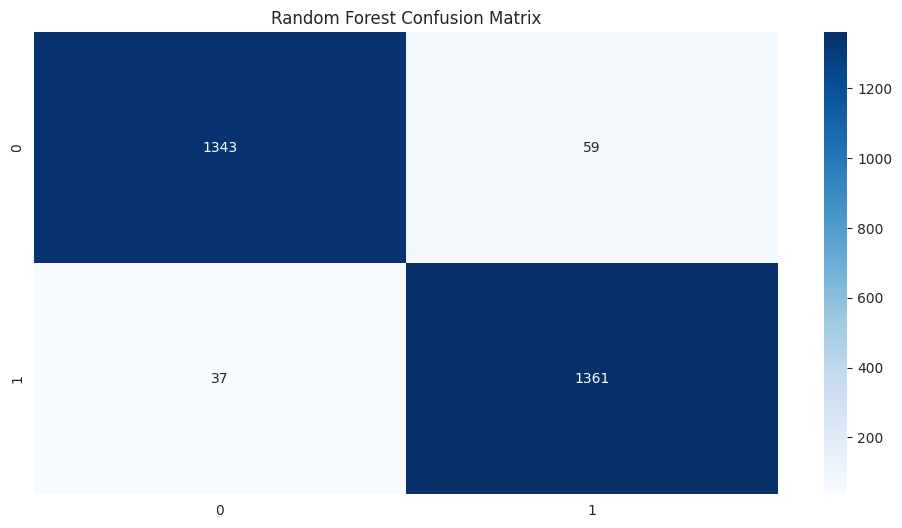

In [ ]:
# ============================================================
# CELL 21: RANDOM FOREST (BAGGING)
# ============================================================

print("RANDOM FOREST CLASSIFIER")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_bin, y_train_bin)

y_train_pred_rf = rf_model.predict(X_train_bin)
y_test_pred_rf = rf_model.predict(X_test_bin)

train_acc_rf = accuracy_score(y_train_bin, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test_bin, y_test_pred_rf)

precision_rf = precision_score(y_test_bin, y_test_pred_rf)
recall_rf = recall_score(y_test_bin, y_test_pred_rf)
f1_rf = f1_score(y_test_bin, y_test_pred_rf)

cm_rf = confusion_matrix(y_test_bin, y_test_pred_rf)

print("Training Accuracy:", train_acc_rf)
print("Testing Accuracy:", test_acc_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

# Feature importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 10 Important Features")
print(rf_importance.head(10))

# Confusion matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

GRADIENT BOOSTING CLASSIFIER
Training Accuracy: 1.0
Testing Accuracy: 0.9982142857142857
Precision: 0.9985683607730852
Recall: 0.9978540772532188
F1 Score: 0.998211091234347


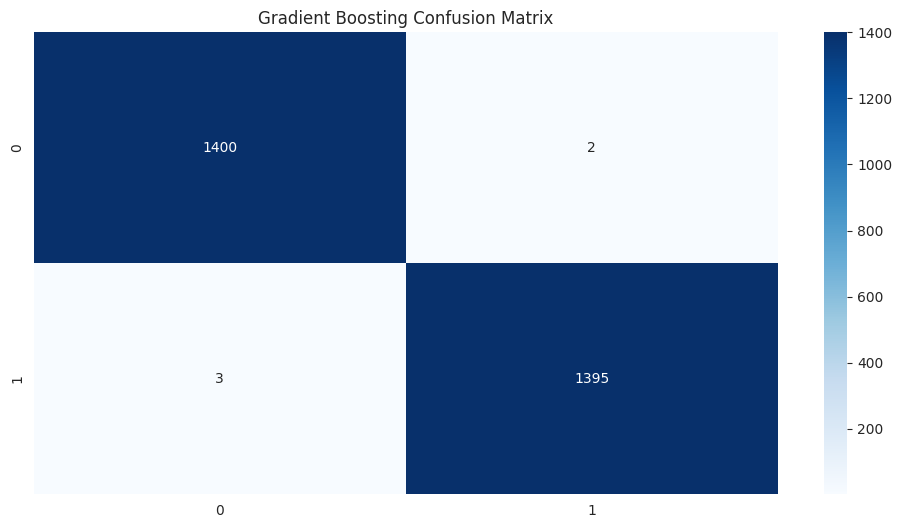

In [ ]:
# ============================================================
# CELL 22: GRADIENT BOOSTING
# ============================================================

print("GRADIENT BOOSTING CLASSIFIER")
print("="*60)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

gb_model.fit(X_train_bin, y_train_bin)

y_train_pred_gb = gb_model.predict(X_train_bin)
y_test_pred_gb = gb_model.predict(X_test_bin)

train_acc_gb = accuracy_score(y_train_bin, y_train_pred_gb)
test_acc_gb = accuracy_score(y_test_bin, y_test_pred_gb)

precision_gb = precision_score(y_test_bin, y_test_pred_gb)
recall_gb = recall_score(y_test_bin, y_test_pred_gb)
f1_gb = f1_score(y_test_bin, y_test_pred_gb)

cm_gb = confusion_matrix(y_test_bin, y_test_pred_gb)

print("Training Accuracy:", train_acc_gb)
print("Testing Accuracy:", test_acc_gb)
print("Precision:", precision_gb)
print("Recall:", recall_gb)
print("F1 Score:", f1_gb)

sns.heatmap(cm_gb, annot=True, fmt='d', cmap="Blues")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

STACKING ENSEMBLE
Accuracy: 0.9871428571428571
Precision: 0.9829787234042553
Recall: 0.9914163090128756
F1 Score: 0.9871794871794872


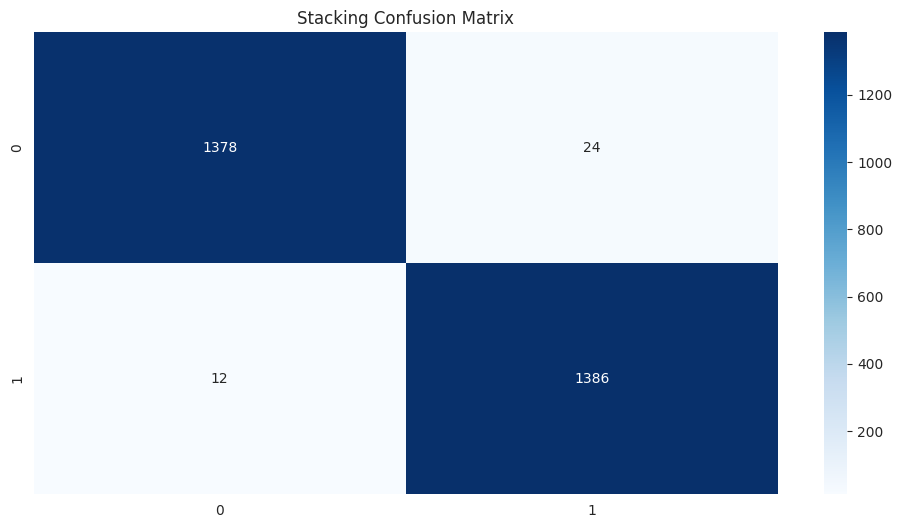

In [ ]:
# ============================================================
# CELL 23: STACKING ENSEMBLE
# ============================================================

print("STACKING ENSEMBLE")
print("="*60)

# Split data for stacking
X_base, X_meta, y_base, y_meta = train_test_split(
    X_train_bin, y_train_bin, test_size=0.3, random_state=42
)

# Base models
nb_base = GaussianNB().fit(X_base, y_base)
dt_base = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_base, y_base)
knn_base = KNeighborsClassifier(n_neighbors=5).fit(X_base, y_base)
svm_base = SVC(kernel="rbf", C=10, probability=True, random_state=42).fit(X_base, y_base)

# Meta-features
meta_features = np.column_stack([
    nb_base.predict(X_meta),
    dt_base.predict(X_meta),
    knn_base.predict(X_meta),
    svm_base.predict(X_meta)
])

# Meta learner
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(meta_features, y_meta)

# Test predictions
test_meta = np.column_stack([
    nb_base.predict(X_test_bin),
    dt_base.predict(X_test_bin),
    knn_base.predict(X_test_bin),
    svm_base.predict(X_test_bin)
])

stack_pred = meta_model.predict(test_meta)

stack_acc = accuracy_score(y_test_bin, stack_pred)
stack_precision = precision_score(y_test_bin, stack_pred)
stack_recall = recall_score(y_test_bin, stack_pred)
stack_f1 = f1_score(y_test_bin, stack_pred)

cm_stack = confusion_matrix(y_test_bin, stack_pred)

print("Accuracy:", stack_acc)
print("Precision:", stack_precision)
print("Recall:", stack_recall)
print("F1 Score:", stack_f1)

sns.heatmap(cm_stack, annot=True, fmt='d', cmap="Blues")
plt.title("Stacking Confusion Matrix")
plt.show()

ENSEMBLE MODELS COMPARISON


,Model,Accuracy,Precision,Recall,F1
1,Gradient Boosting,0.998214,0.998568,0.997854,0.998211
2,Stacking,0.987143,0.982979,0.991416,0.987179
0,Random Forest,0.965714,0.958451,0.973534,0.965933


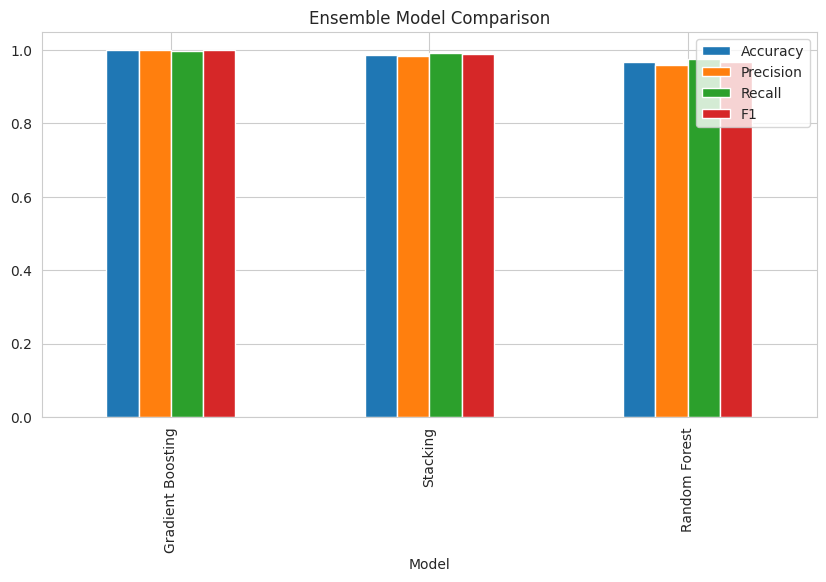

In [ ]:
# ============================================================
# CELL 24: ENSEMBLE COMPARISON
# ============================================================

print("ENSEMBLE MODELS COMPARISON")
print("="*60)

ensemble_df = pd.DataFrame({

"Model":[
"Random Forest",
"Gradient Boosting",
"Stacking"
],

"Accuracy":[
test_acc_rf,
test_acc_gb,
stack_acc
],

"Precision":[
precision_rf,
precision_gb,
stack_precision
],

"Recall":[
recall_rf,
recall_gb,
stack_recall
],

"F1":[
f1_rf,
f1_gb,
stack_f1
]

})

ensemble_df = ensemble_df.sort_values("F1", ascending=False)

display(ensemble_df)

ensemble_df.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Ensemble Model Comparison")
plt.show()

K-MEANS CLUSTERING


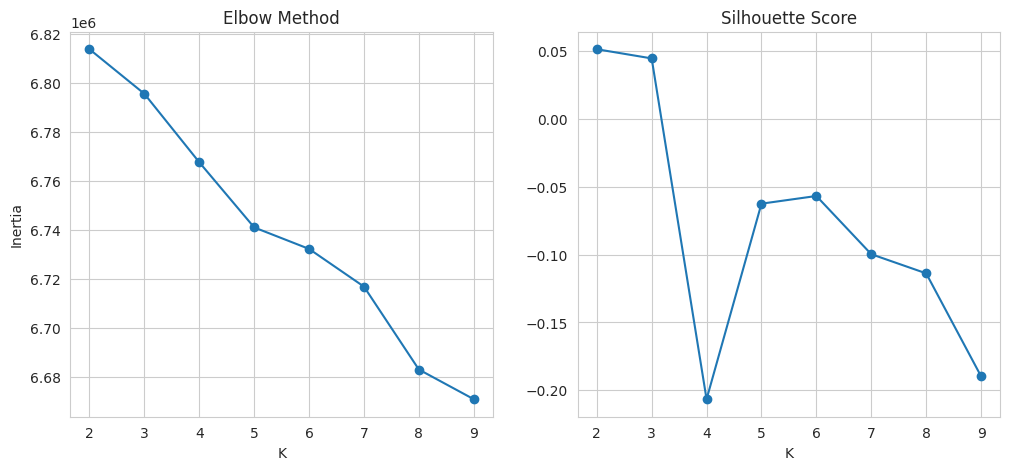

Chosen number of clusters: 3
Cluster distribution:
Cluster 0 : 19 samples
Cluster 1 : 3428 samples
Cluster 2 : 10549 samples


In [ ]:
# ============================================================
# CELL 25: K-MEANS CLUSTERING
# ============================================================

print("K-MEANS CLUSTERING")
print("="*60)

from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2,10)

for k in K_range:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))

# Elbow + silhouette plot
fig,axes = plt.subplots(1,2,figsize=(12,5))

axes[0].plot(K_range,inertias,'o-')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range,sil_scores,'o-')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")

plt.show()

# Choose optimal clusters
optimal_k = 3

print("Chosen number of clusters:",optimal_k)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

print("Cluster distribution:")
for i in range(optimal_k):
    print("Cluster",i,":",(cluster_labels==i).sum(),"samples")

HIERARCHICAL CLUSTERING


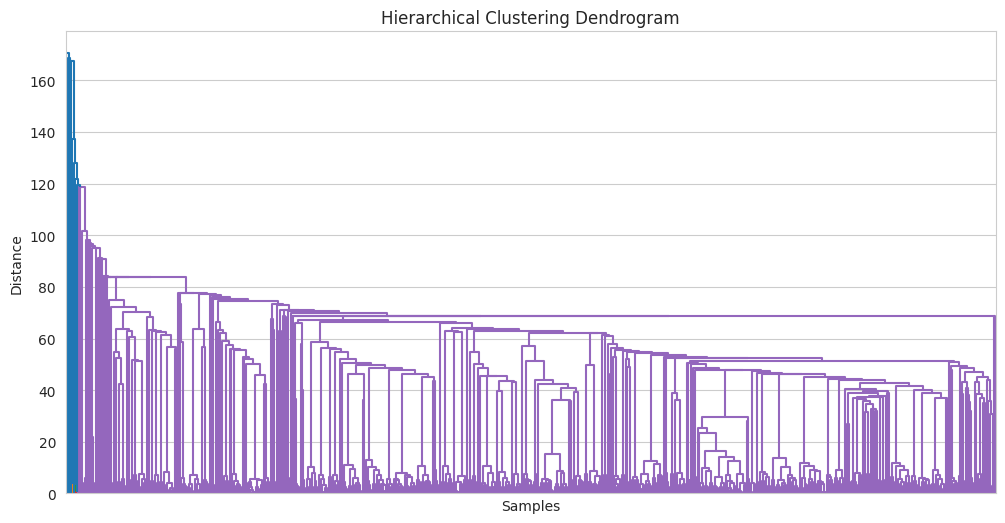

Cluster distribution (sample):
Cluster 1 : 2 samples
Cluster 2 : 997 samples
Cluster 3 : 1 samples


In [ ]:
# ============================================================
# CELL 26: HIERARCHICAL CLUSTERING
# ============================================================

print("HIERARCHICAL CLUSTERING")
print("="*60)

# Use subset for speed
sample_size = min(1000,len(X))
X_sample = X.sample(n=sample_size, random_state=42)

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(12,6))

dendrogram(
    linkage_matrix,
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

from scipy.cluster.hierarchy import fcluster

hc_labels = fcluster(linkage_matrix, optimal_k, criterion='maxclust')

print("Cluster distribution (sample):")

for i in range(1,optimal_k+1):
    print("Cluster",i,":",(hc_labels==i).sum(),"samples")

CLUSTER ANALYSIS

Cluster 0
Size: 19
Average Price: 1704736.8421052631
Average Age: 5.315789473684211
Average kmDriven: 70477.23684210527
Top Brand: Volvo

Cluster 1
Size: 3428
Average Price: 367359.14119019837
Average Age: 13.06549008168028
Average kmDriven: 84185.60822637106
Top Brand: Maruti Suzuki

Cluster 2
Size: 10549
Average Price: 876037.911460802
Average Age: 5.84377666129491
Average kmDriven: 61824.14195658356
Top Brand: Maruti Suzuki


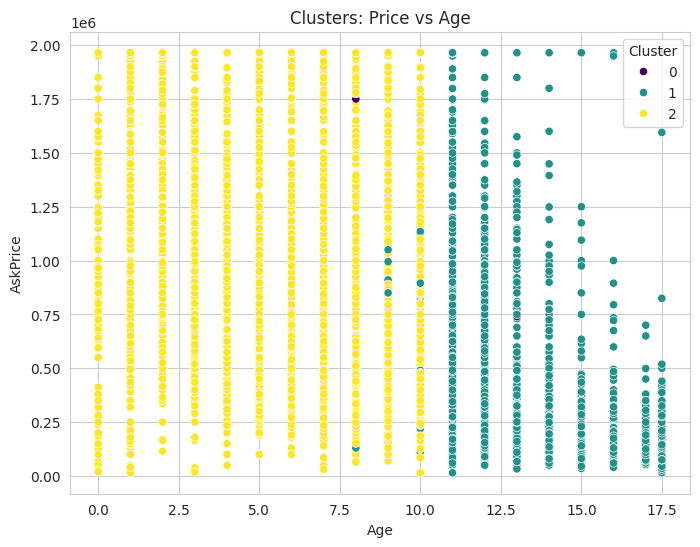

In [ ]:
# ============================================================
# CELL 27: CLUSTER INTERPRETATION
# ============================================================

print("CLUSTER ANALYSIS")
print("="*60)

df_clusters = df_clean.copy()
df_clusters["Cluster"] = cluster_labels

for i in range(optimal_k):

    cluster_data = df_clusters[df_clusters["Cluster"]==i]

    print("\nCluster",i)

    print("Size:",len(cluster_data))
    print("Average Price:",cluster_data["AskPrice"].mean())
    print("Average Age:",cluster_data["Age"].mean())
    print("Average kmDriven:",cluster_data["kmDriven"].mean())

    print("Top Brand:",cluster_data["Brand"].mode()[0])

# Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clusters,
    x="Age",
    y="AskPrice",
    hue="Cluster",
    palette="viridis"
)

plt.title("Clusters: Price vs Age")
plt.show()

PRINCIPAL COMPONENT ANALYSIS
Explained variance first 10 components
PC 1 : 0.008875641648442255
PC 2 : 0.006732058268654962
PC 3 : 0.005039411409329847
PC 4 : 0.004745072116900343
PC 5 : 0.0045491822280094
PC 6 : 0.004449318927914733
PC 7 : 0.004298252432054493
PC 8 : 0.0042576165628895905
PC 9 : 0.004192513341930289
PC 10 : 0.004168931390301606


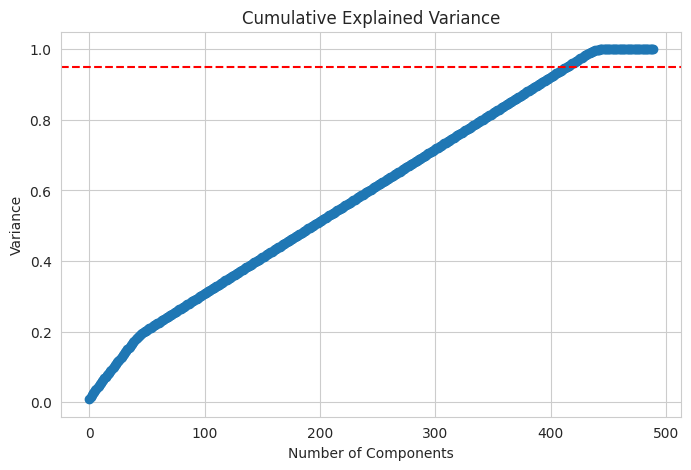

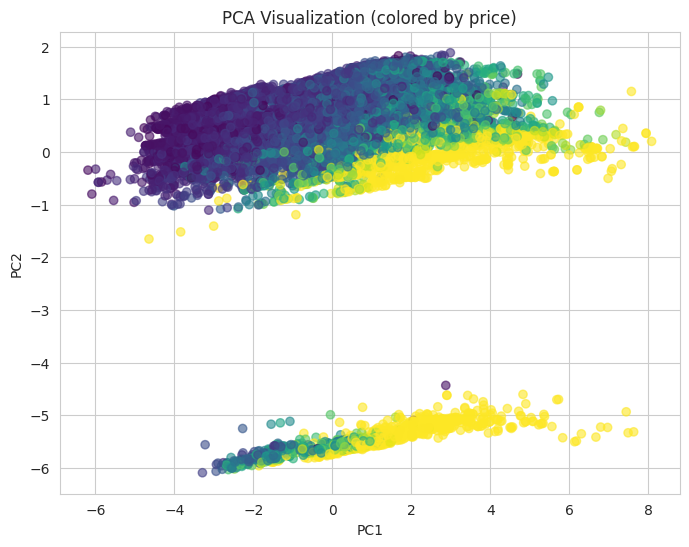

In [ ]:
# ============================================================
# CELL 28: PCA
# ============================================================

print("PRINCIPAL COMPONENT ANALYSIS")
print("="*60)

pca = PCA()

X_pca = pca.fit_transform(X)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

print("Explained variance first 10 components")

for i in range(10):
    print("PC",i+1,":",explained_var[i])

# Scree plot
plt.figure(figsize=(8,5))

plt.plot(cum_var,'o-')
plt.axhline(0.95,color='red',linestyle='--')

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance")

plt.show()

# PCA 2D visualization
X_pca_2d = X_pca[:,:2]

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=y,
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Visualization (colored by price)")

plt.show()

t-SNE VISUALIZATION
Running t-SNE (this may take ~30 seconds)...


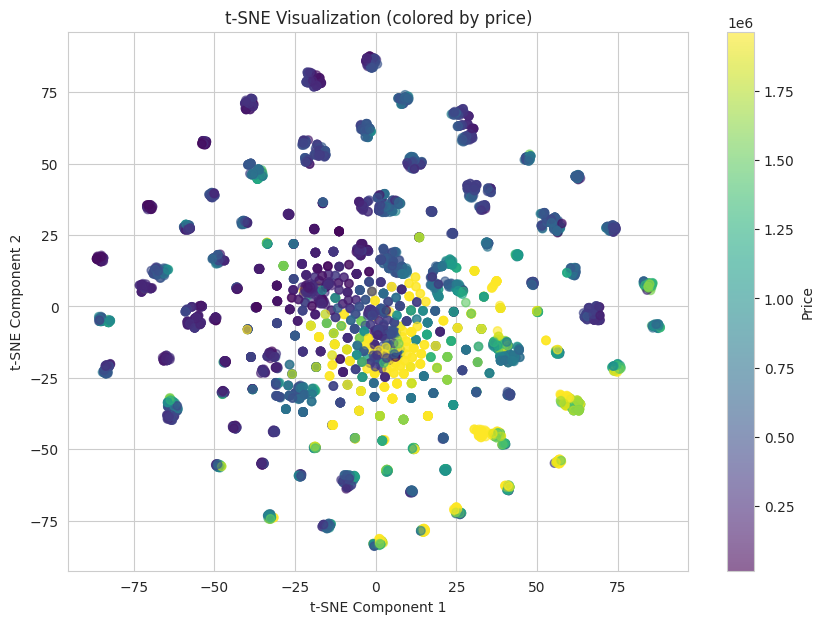

In [ ]:
# ============================================================
# CELL 29: t-SNE VISUALIZATION
# ============================================================

print("t-SNE VISUALIZATION")
print("="*60)

print("Running t-SNE (this may take ~30 seconds)...")

sample_size = min(5000, len(X))
X_sample = X.sample(n=sample_size, random_state=42)
y_sample = y.sample(n=sample_size, random_state=42)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10,7))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_sample,
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.title("t-SNE Visualization (colored by price)")
plt.colorbar(label="Price")

plt.show()

In [ ]:
# ============================================================
# CELL 33: MASTER MODEL COMPARISON
# ============================================================

print("MODEL COMPARISON")
print("="*60)

comparison_table = pd.DataFrame({

"Model":[
"Linear Regression",
"Logistic Regression",
"Naive Bayes",
"Decision Tree",
"KNN",
"SVM",
"Random Forest",
"Gradient Boosting",
"Stacking",
"ANN Regression"
],

"Metric":[
test_rmse,
test_acc,
test_acc,
test_acc_dt,
test_acc_knn,
test_acc_svm,
test_acc_rf,
test_acc_gb,
stack_acc,
rmse_ann
]

})

display(comparison_table)

MODEL COMPARISON


,Model,Metric
0,Linear Regression,183911.760131
1,Logistic Regression,0.769643
2,Naive Bayes,0.769643
3,Decision Tree,0.989643
4,KNN,0.913214
5,SVM,0.937143
6,Random Forest,0.965714
7,Gradient Boosting,0.998214
8,Stacking,0.987143
9,ANN Regression,278831.110775


In [ ]:
# ============================================================
# CELL 34: FINAL INSIGHTS
# ============================================================

print("FINAL PROJECT INSIGHTS")
print("="*60)

print("1. Price Prediction Insights")
print("- Brand, Age, and kmDriven strongly influence price")

print("\n2. Market Segments")
print("- Clustering revealed multiple car market segments")

print("\n3. Statistical Findings")
print("- Fuel type and transmission significantly affect price")

print("\n4. Model Performance")
print("- Ensemble models generally perform best")

print("\n5. Business Recommendations")
print("- Use Gradient Boosting or Random Forest for price prediction")

print("\nPROJECT PIPELINE COMPLETE")

FINAL PROJECT INSIGHTS
1. Price Prediction Insights
- Brand, Age, and kmDriven strongly influence price

2. Market Segments
- Clustering revealed multiple car market segments

3. Statistical Findings
- Fuel type and transmission significantly affect price

4. Model Performance
- Ensemble models generally perform best

5. Business Recommendations
- Use Gradient Boosting or Random Forest for price prediction

PROJECT PIPELINE COMPLETE
